In [141]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# Question 4

In [142]:
# parameters
g = 9.81

In [143]:
# Define Weibull parameters
# shape = 2.2     # shape parameter (k)
# loc = 15        # location parameter
depth = 7.3


wind = { "direction": ['NNE', 'NE', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW', 'N'],
        "angle": [67.5, 90, 90, 67.5, 45, 22.5, 0, 22.5, 45],
        "fetch": [21300, 32415, 70420, 51500, 35430, 26450, 21990, 17860, 17000],
        "scale": [17, 14, 16, 14, 16, 14, 15, 13, 12],
        "shape": [2.3, 2.3, 2.3, 2.3, 2.1, 2.2, 2.2, 2.4, 2.6],
        "depth": [depth, depth, depth, depth, depth, depth, depth, depth, depth],}
wind = pd.DataFrame(wind)

C:\Users\TUDelftSID\AppData\Local\Temp\ipykernel_30340\541923499.py:17: RuntimeWarning: divide by zero encountered in divide
  rtp_MC = 1 / (1 - cdf_MC)


0.9475371672734267


,direction,angle,fetch,scale,shape,depth,speed95
0,NNE,67.5,21300,17,2.3,7.3,27.39
1,NE,90.0,32415,14,2.3,7.3,22.56
2,SW,90.0,70420,16,2.3,7.3,25.78
3,WSW,67.5,51500,14,2.3,7.3,22.56
4,W,45.0,35430,16,2.1,7.3,26.98
5,WNW,22.5,26450,14,2.2,7.3,23.05
6,NW,0.0,21990,15,2.2,7.3,24.70
7,NNW,22.5,17860,13,2.4,7.3,20.53
8,N,45.0,17000,12,2.6,7.3,18.30


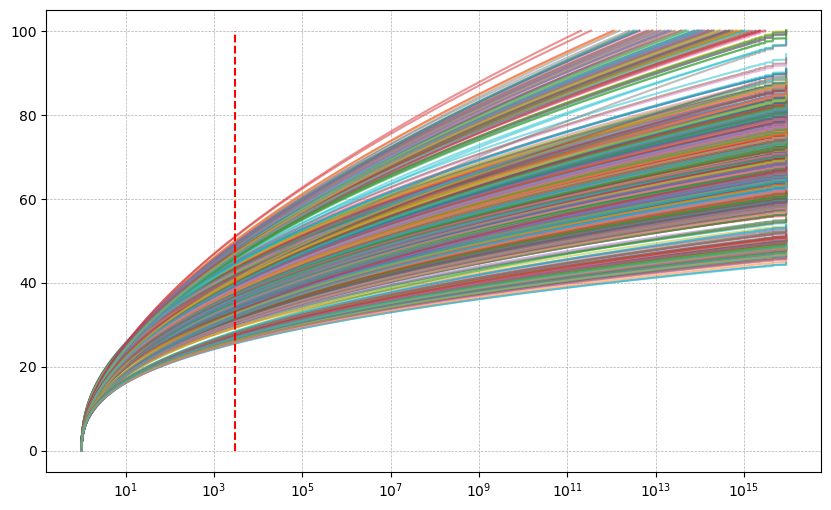

In [144]:
speed95 = []
n_btstrap = 100
n_samples = 1000
u = np.linspace(0, 100, n_samples)

fig,ax = plt.subplots(figsize=(10, 6))
# ax.vlines(3000, 0, 1)
ax.set_xscale('log')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
for i in range(9):
    synth_data = stats.weibull_min.rvs(c=wind.loc[i, 'shape'], scale=wind.loc[i, 'scale'], size=n_samples)
    bootstrap = []
    for j in range(n_btstrap):
        sample_MC = np.random.choice(synth_data, size=n_samples, replace=True)
        params = stats.weibull_min.fit(sample_MC)
        cdf_MC = stats.weibull_min.cdf(u, *params)
        rtp_MC = 1 / (1 - cdf_MC)
        bootstrap.append(rtp_MC)

        ax.plot(rtp_MC, u, label=f'Bootstrap {j+1}', alpha=0.5)
        # Calculate the 95th percentile speed
    upper_bound = stats.weibull_min.ppf(0.95, c=wind.loc[i, 'shape'], scale=wind.loc[i, 'scale'])
    speed95.append(round(upper_bound, 2))
ax.vlines(3000, 0, 100, color='red', linestyle='--', label='3000 m/s')
print(stats.weibull_min.cdf(18.6, c=2.3, loc=17))

wind['speed95'] = speed95
display(wind)

In [145]:
H_inf = 0.14 # standard parameter
T_inf = 7.69 # standard parameter
H_m0 = []
T_p =[]

for i in range(9):
    F_tilde = (g*wind.loc[i, 'fetch'])/(wind.loc[i, 'speed95']**2)
    d_tilde = (g*wind.loc[i, 'depth'])/(wind.loc[i, 'speed95']**2)

    H_term1 = np.tanh(0.343*(d_tilde**1.14))
    H_term2 = 4.41*(10**-4)*(F_tilde**0.79)
    H_tilde = H_inf* (H_term1 * np.tanh(H_term2/H_term1))**0.572

    T_term1 = np.tanh(0.10*(d_tilde**2.01))
    T_term2 = 2.77*(10**-7)*(F_tilde**1.45)
    T_tilde = T_inf* (T_term1 * np.tanh(T_term2/T_term1))**0.187
    
    H_m0.append(round(H_tilde*(wind.loc[i, 'speed95']**2)/g,2))
    T_p.append(round(T_tilde*(wind.loc[i, 'speed95']/g),2))

wind['H_m0'] = H_m0
wind['T_p'] = T_p

display(wind)

,direction,angle,fetch,scale,shape,depth,speed95,H_m0,T_p
0,NNE,67.5,21300,17,2.3,7.3,27.39,1.20,5.53
1,NE,90.0,32415,14,2.3,7.3,22.56,1.07,5.42
2,SW,90.0,70420,16,2.3,7.3,25.78,1.20,5.69
3,WSW,67.5,51500,14,2.3,7.3,22.56,1.09,5.50
4,W,45.0,35430,16,2.1,7.3,26.98,1.23,5.73
5,WNW,22.5,26450,14,2.2,7.3,23.05,1.07,5.36
6,NW,0.0,21990,15,2.2,7.3,24.70,1.11,5.36
7,NNW,22.5,17860,13,2.4,7.3,20.53,0.91,4.80
8,N,45.0,17000,12,2.6,7.3,18.30,0.81,4.52


# Question 5

In [146]:
h = depth # water depth in front of the dike
H = 7.0 # height of the dike

In [147]:
tan_a = 1/5 # slop of the dike
# R_C = H - (h-2) # freeboard of the dike
# print(f'R_C = {R_C}')
R_C = 1.7
gamma_b = 1.0 # influence factor for a berm
gamma_f = 0.95 # influence factor for roughness elements on the slope
gamma_nu = 1.0 # influence factor for a wall at the end of a slope

L_deep = []
xi_m10 = []
q = []
for i in range(9):
    H_m0 = wind.loc[i, 'H_m0'] 
    beta = wind.loc[i, 'angle']
    T_p = wind.loc[i, 'T_p']
    L_deepval = (g*T_p**2)/(2*np.pi)
    L_deep.append(round(L_deepval,2))
    xi_m10val = tan_a/(np.sqrt(H_m0/L_deepval))
    xi_m10.append(round(xi_m10val,3))
    gamma_runover = 1 - 0.0033 * beta
    q_term1 = 0.026 / np.sqrt(tan_a)
    q_term2 = R_C / (xi_m10val * H_m0 * gamma_b * gamma_f * gamma_runover * gamma_nu)
    q_term3 = np.sqrt(g * (H_m0**3))

    q.append(round(q_term1 * gamma_b * xi_m10val * np.exp(-(2.5 * q_term2)**1.3) * q_term3 * 1000, 3))

wind['L_deep'] = L_deep
wind['xi_m10'] = xi_m10
wind['q (l/s/s)'] = q

display(wind)

,direction,angle,fetch,scale,shape,depth,speed95,H_m0,T_p,L_deep,xi_m10,q (l/s/s)
0,NNE,67.5,21300,17,2.3,7.3,27.39,1.20,5.53,47.75,1.262,1.035
1,NE,90.0,32415,14,2.3,7.3,22.56,1.07,5.42,45.87,1.309,0.207
2,SW,90.0,70420,16,2.3,7.3,25.78,1.20,5.69,50.55,1.298,0.611
3,WSW,67.5,51500,14,2.3,7.3,22.56,1.09,5.50,47.23,1.317,0.621
4,W,45.0,35430,16,2.1,7.3,26.98,1.23,5.73,51.26,1.291,2.812
5,WNW,22.5,26450,14,2.2,7.3,23.05,1.07,5.36,44.86,1.295,1.634
6,NW,0.0,21990,15,2.2,7.3,24.70,1.11,5.36,44.86,1.271,3.065
7,NNW,22.5,17860,13,2.4,7.3,20.53,0.91,4.80,35.97,1.257,0.297
8,N,45.0,17000,12,2.6,7.3,18.30,0.81,4.52,31.90,1.255,0.035


In [148]:
xi_m10 = wind.loc[wind['direction'] == 'NW', 'xi_m10'].values[0]
H_m0 = wind.loc[wind['direction'] == 'NW', 'H_m0'].values[0]
beta = wind.loc[wind['direction'] == 'NW', 'angle'].values[0]
gamma_runover = 1 - 0.0033 * beta
q = (0.026/np.sqrt(tan_a)) * gamma_b * xi_m10 * np.exp(-(2.5*(R_C/(xi_m10*H_m0*gamma_b*gamma_f*gamma_runover*gamma_nu)))**1.3) * np.sqrt(g* (H_m0**3))
print(f'The overtopping discharge is {q*1000:.3f} l/m/s per meter of dike length.')

The overtopping discharge is 3.059 l/m/s per meter of dike length.


In [149]:
q=5 / 1000
RC = ((xi_m10 * H_m0 * gamma_b * gamma_f * gamma_runover * gamma_nu) / 2.5) * ((-np.log(q*np.sqrt(tan_a)/(0.026*gamma_b*xi_m10*np.sqrt(g*(H_m0**3)))))**(1/1.3))
print(f'The freeboard needed is {RC:.2f} m')
wind.drop(['L_deep', 'xi_m10'], axis=1, inplace=True)
display(wind)
wind.to_latex('wind_data.tex', index=False, float_format="%.2f", escape=False)

The freeboard needed is 1.55 m


,direction,angle,fetch,scale,shape,depth,speed95,H_m0,T_p,q (l/s/s)
0,NNE,67.5,21300,17,2.3,7.3,27.39,1.20,5.53,1.035
1,NE,90.0,32415,14,2.3,7.3,22.56,1.07,5.42,0.207
2,SW,90.0,70420,16,2.3,7.3,25.78,1.20,5.69,0.611
3,WSW,67.5,51500,14,2.3,7.3,22.56,1.09,5.50,0.621
4,W,45.0,35430,16,2.1,7.3,26.98,1.23,5.73,2.812
5,WNW,22.5,26450,14,2.2,7.3,23.05,1.07,5.36,1.634
6,NW,0.0,21990,15,2.2,7.3,24.70,1.11,5.36,3.065
7,NNW,22.5,17860,13,2.4,7.3,20.53,0.91,4.80,0.297
8,N,45.0,17000,12,2.6,7.3,18.30,0.81,4.52,0.035


# Question 7

In [150]:
gamma_w = 10000 # unit weight of the water
gamma_s = 16500 # unit weight of the submerged particle
d70 = 2.8e-4 # 70%-fractile of grain size distribution
d70_m = 2.08e-4 # Reference value of 70%-fractile of grain size dis-tribution
L = 45.4 + 5 # piping length
H = 5.3 # water level at the foreside of the dike
tan_theta = 1/3.3 # slope of the dike
k = 7.52e-4 # hydraulic conductivity of the auqifer
D = 6.0 # thickness of the aquifer
eta = 0.25 # Drag factor coefficient 
m_p = 1 # Model factor piping
nu = 1.33e-6 # Kinematic viscosity 
g = 9.81 # Gravitational acceleration
h_b = 0 # water level on the hinter side of the dike
d = 2.5 - 0.5 # impermeable sand layer at the sand boil exit point
rho_sub = 1.25 # factor of safety



In [151]:
def Limit_state_Sellmeijer(L, H, d70_m, d70, tan_theta, k, D, eta, m_p, nu, g, h_b, d, rho_sub):
    F_R = (eta*(gamma_s/gamma_w)*tan_theta)
    F_S = ((d70_m / ((nu*k*L/g)**(1/3))) * ((d70/d70_m)**0.4))
    step_1 = ((D/L)**2.8)-1
    step_2 = (0.28/step_1)+0.04
    F_G = (0.91* (D/L)**step_2)
    H_c = m_p * F_R * F_S * F_G * L / rho_sub
    Z = H_c - (H - h_b - d*0.3)
    return Z, H_c

In [152]:
Z, H_c = Limit_state_Sellmeijer(L, H, d70_m, d70, tan_theta, k, D, eta, m_p, nu, g, h_b, d, rho_sub)
print(f'The critical hydraulic head difference is {H_c:.2f} m.')
print(f'The limit state {Z:.2f} m.')

The critical hydraulic head difference is 1.04 m.
The limit state -3.66 m.


# Question 8

In [153]:
H_c = ((1/3)*L + 12)/6 +5/8.5
Z = H_c - (H - h_b - d*0.3)
print(f'the critical hydraulic head difference is {H_c:.2f} m')
print(f'The limit state {Z:.2f} m.')

the critical hydraulic head difference is 5.39 m
The limit state 0.69 m.
